# Problem Set: Housing Supply Elasticity and Geographic Constraints

## Background

This problem set is based on Saiz (2010) "The Geographic Determinants of Housing Supply," which examines how geographic constraints affect housing supply elasticity across U.S. metropolitan areas. The original paper shows that areas with more undevelopable land (due to steep slopes, water bodies, etc.) have less elastic housing supply, leading to higher price volatility.

In this simplified version, we will estimate the relationship between housing supply growth and price changes from 1980-2010, focusing on how geographic constraints moderate this relationship.

## The Model

We estimate the following instrumental variables specification:

**Δlog(Price) = β₁ × Δlog(HousingUnits) + β₂ × [Δlog(HousingUnits) × UndevelopableShare] + Region Controls + ε**

Where:
- **Δlog(Price)**: Log change in median home values (1980-2010)  
- **Δlog(HousingUnits)**: Log change in housing units (1980-2010)
- **UndevelopableShare**: Share of metropolitan area that cannot be developed
- **Region Controls**: Census region fixed effects

The endogenous variables (housing growth terms) are instrumented using **Bartik shift-share instruments** based on predicted employment growth from national industry trends and local industrial composition.

## Key Economic Predictions

1. **β₁ > 0**: In unconstrained areas (UndevelopableShare = 0), housing supply changes should be associated with price increases (positive price elasticity)
2. **β₂ > 0**: Geographic constraints should **increase** price responsiveness - constrained areas show larger price responses to supply changes

---

## Question 1: Setup and Data Exploration [1 point]

### Part A: Import Libraries and Set Working Directory

Import the required libraries and set up your working directory:

**Required libraries:**
- `pandas` (as pd) (for data manipulation)
- `numpy` (as np) (for numerical operations)  
- `os` (for file path operations)
- `matplotlib.pyplot` (as plt) (for graphing - Q3)
- `linearmodels.iv.IV2SLS` (for instrumental variables regression)

Define a `working_dir` variable pointing to your Saiz project folder.

### Part B: Load and Inspect the Dataset

Load the regression-ready dataset from `processed_data/regression_data_saiz-like.csv` (relative to your working directory).

### Part C: Produce Summary Statistics

Generate the following descriptive statistics:

1. **Dataset overview**: Use `.info()` to show data types and missing values
2. **Continuous variables**: Calculate mean and standard deviation for:
   - `logdiff_mv_1980_2010` (dependent variable)
   - `logdiff_hu_1980_2010` (endogenous variable 1) 
   - `logdiff_hu_x_undev` (endogenous variable 2)
   - `undevelopable_share` (key explanatory variable)
   - All four Bartik instruments: `bartik_emp_80_87`, `bartik_emp_88_97`, `bartik_emp_80_87_x_undev`, `bartik_emp_88_97_x_undev`

3. **Categorical variable**: Show value counts for `census_region`

4. **Geographic coverage**: Report the number of unique CBSAs in the dataset

**Hints**: 
- Use `.describe()` for continuous variables and `.value_counts()` for categorical variables
- To count unique CBSAs, use `df['CBSA Code'].nunique()` (the dataset contains a 'CBSA Code' column)

Note: Problem set continues below

In [13]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import pip
import seaborn as sns
import numpy as np
import os
from pathlib import Path
try:
    from linearmodels.iv import IV2SLS
except ImportError:
    pip.main(['install', 'linearmodels'])
    from linearmodels.iv import IV2SLS


In [14]:
# Question 1 Solution

# Part A: Import Libraries and Set Working Directory
## your code here 
UrbanEconomics_dir = Path(f"C:/Users/nicho/Documents/JHU/Urban Economics")
working_dir = UrbanEconomics_dir / "assignments/week 6-7"

# Part B: Load and Inspect the Dataset
data_file_name = "regression_data_saiz-like.csv"
df = pd.read_csv(working_dir / data_file_name)

print("="*50)  # Separator for clarity in output
# Part C: Produce Summary Statistics
# 1. Dataset overview
print(df.info())

print("="*50)  # Separator for clarity in output
# 2. Continuous variables - mean and standard deviation
continuous_vars = ['logdiff_mv_1980_2010',  # dependent variable
                   'logdiff_hu_1980_2010',  # endogenous variable 1
                   'logdiff_hu_x_undev',  # endogenous variable 2
                   'undevelopable_share',  # key explanatory variable
                   'bartik_emp_80_87', 'bartik_emp_88_97', 'bartik_emp_80_87_x_undev', 'bartik_emp_88_97_x_undev']  # Bartik instruments
print(df[continuous_vars].describe())

print("="*50)  # Separator for clarity in output
# 3. Categorical variable - value counts for census_region
cat_vars = ['census_region']
for var in cat_vars:
    print(f"Value counts for {var}:")
    print(df[var].value_counts())
    print("\n")

print("="*50)  # Separator for clarity in output
# 4. Geographic coverage - number of unique CBSAs
print(f"Number of unique CBSAs: {df['CBSA Code'].nunique()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CBSA Code                 99 non-null     int64  
 1   NAME                      99 non-null     object 
 2   logdiff_mv_1980_2010      99 non-null     float64
 3   logdiff_hu_1980_2010      99 non-null     float64
 4   logdiff_hu_x_undev        99 non-null     float64
 5   bartik_emp_80_87          99 non-null     float64
 6   bartik_emp_88_97          99 non-null     float64
 7   bartik_emp_80_87_x_undev  99 non-null     float64
 8   bartik_emp_88_97_x_undev  99 non-null     float64
 9   undevelopable_share       99 non-null     float64
 10  census_region             99 non-null     object 
 11  log_hu_1980               99 non-null     float64
 12  hu_1980                   99 non-null     int64  
 13  hu_2010                   99 non-null     int64  
 14  mv_1980_cbsa

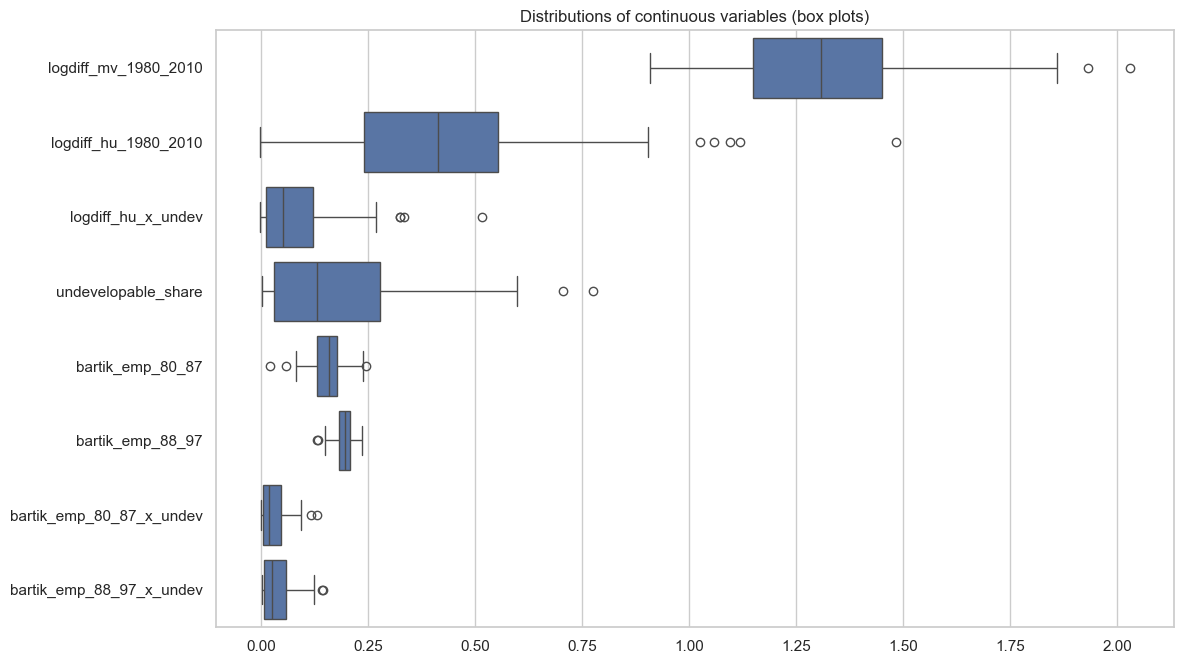

In [15]:
# Box plots for continuous variables (quick distribution check)
sns.set_theme(style="whitegrid")

cols = [c for c in continuous_vars if c in df.columns]
missing = sorted(set(continuous_vars) - set(cols))
if missing:
    print(f"Warning: missing columns skipped: {missing}")

data_long = df[cols].melt(var_name="variable", value_name="value")

plt.figure(figsize=(12, 0.6 * len(cols) + 2))
ax = sns.boxplot(data=data_long, y="variable", x="value", orient="h")
ax.set_title("Distributions of continuous variables (box plots)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Question 2: Instrumental Variables Regression [1 point]

Now we will estimate the relationship between housing supply growth and price changes using instrumental variables regression. We will run **two specifications** to understand how geographic constraints affect housing supply elasticity.

### Part A: Simple IV Regression (Average Elasticity)

First, estimate a simple model without geographic constraint interactions to get the **average housing supply elasticity** across all metropolitan areas:

**Model 1:** `logdiff_mv_1980_2010 ~ logdiff_hu_1980_2010 + census_region_controls`

**Instructions:**
1. **Prepare categorical variables**: Use `pd.get_dummies()` to convert `census_region` into dummy variables
   - Set `drop_first=True` to avoid the dummy variable trap
   - This creates binary variables for each region except the first (reference category)

2. **Define model components**:
   - **Dependent variable**: `logdiff_mv_1980_2010` 
   - **Endogenous variable**: `logdiff_hu_1980_2010` (only housing growth, no interaction)
   - **Instruments**: `bartik_emp_80_87` and `bartik_emp_88_97` (only direct Bartik instruments)
   - **Exogenous controls**: Constant + region dummy variables

3. **Estimate the model**: Use `IV2SLS()` from linearmodels with the following syntax:
   ```python
   model = IV2SLS(dependent=y, exog=X_exog, endog=X_endog, instruments=Z)
   results = model.fit(cov_type='robust')

### Part B: Full Saiz Model with Geographic Constraints

Now estimate the full model that allows geographic constraints to moderate housing supply elasticity:

**Model 2:** `logdiff_mv_1980_2010 ~ logdiff_hu_1980_2010 + logdiff_hu_x_undev + census_region_controls`

**Instructions:**
1. **Define model components**:
   - **Dependent variable**: `logdiff_mv_1980_2010` (same as before)
   - **Endogenous variables**: Both `logdiff_hu_1980_2010` AND `logdiff_hu_x_undev` (housing growth + interaction term)
   - **Instruments**: All four Bartik instruments: `bartik_emp_80_87`, `bartik_emp_88_97`, `bartik_emp_80_87_x_undev`, `bartik_emp_88_97_x_undev`
   - **Exogenous controls**: Same as Model 1 (constant + region dummy variables)

2. **Estimate the full model**: Use the same `IV2SLS()` syntax but with expanded endogenous variables and instruments

3. **Extract key coefficients**:
   - **β₁**: Coefficient on `logdiff_hu_1980_2010` (elasticity in unconstrained areas)
   - **β₂**: Coefficient on `logdiff_hu_x_undev` (how constraints modify elasticity)

Note: Problem set continues below

In [11]:
# Question 2 Solution: Instrumental Variables Regression

# Part A: Simple IV Regression (Average Elasticity)
# your code here

# 1. Prepare categorical variables - convert census_region to dummy variables
# your code here

# 2. Define model components for Simple IV
# Dependent variable
# your code here

# Exogenous variables (constant + region controls)
# your code here

# Endogenous variables (only housing growth, no interaction)
# your code here

# Instruments (only direct Bartik instruments)
# your code here

# 3. Estimate Simple IV Model
# your code here

# Extract and interpret key coefficient
# your code here

# Part B: Full Saiz Model with Geographic Constraints
# your code here

# Define model components for Full Saiz Model
# Endogenous variables (housing growth + interaction with undevelopable share)
# your code here

# Instruments (all four Bartik instruments)
# your code here

# Exogenous controls remain the same
# your code here
 
# Estimate Full Saiz Model
# your code here

# Extract and interpret key coefficients
# your code here

## Question 3: Visualizing Price Elasticity by Geographic Constraints [1 point]

Now we'll create a visualization to show how price elasticity (price response to housing supply changes) varies across the range of geographic constraints, using the coefficients from your full Saiz model (Model 2).

### Part A: Create Price Elasticity Function

Using your estimates of β₁ and β₂ from Model 2, create a function that calculates the price elasticity at any level of undevelopable share:

**Price Elasticity Function:** `price_elasticity(undevelopable_share) = β₁ + β₂ × undevelopable_share`

Hint: Use `def ... :` to create the function.

### Part B: Generate Price Elasticity Curve

Create a visualization showing how price elasticity varies with geographic constraints:

**Instructions:**
1. **Create data for plotting**:
   - Generate an array of undevelopable share values from 0 to 1 (use `np.linspace(0, 1, 100)` for smooth curve)
   - Calculate corresponding price elasticity values using your function from Part A

2. **Create the plot**:
   - Use matplotlib to create a line plot
   - X-axis: Undevelopable share (0 to 1)  
   - Y-axis: Price elasticity (price response to supply changes)
   - Add horizontal line at the elasticity from Question 2 Part A.
   - Include proper axis labels and title

### Part C: Economic Interpretation

Based on your visualization, discuss:

1. **Comparison to Saiz paper** How do these estimates compare to those from the Saiz (2010) paper?

2. **Comparison to data**: What is the largest undevelopable share? What is the expected price elasticity for this CBSA? What if undevelopable share is 0?

In [12]:
# Question 3 Solution: Visualizing Housing Supply Elasticity by Geographic Constraints

# Part A: Create Elasticity Function
# your code here

# Define price elasticity function using coefficients from Model 2
def price_elasticity_function(undevelopable_share):
    pass
    # your code here

# Part B: Generate Elasticity Curve
# your code here

# 1. Create data for plotting
# your code here

# 2. Create the plot
# your code here

# Main price elasticity curve
# your code here

# Add horizontal line at elasticity from Question 2 Part A (average elasticity)
# your code here

# Formatting
# your code here

# Set reasonable axis limits
# your code here

# Part C: Economic Interpretation
# your code here

# 1. Comparison to Saiz paper
# your code here

# 2. Comparison to data - find extremes
# your code here

# Calculate price elasticities at key points
# your code here